# Regresión Logística - Predicción de Supervivencia de Cirrosis

Modelo LogisticRegression para predecir supervivencia de pacientes con cirrosis primaria biliar (PBC).

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import joblib
import json
import os

#Cargar los datos
df = pd.read_csv('cirrhosis.csv')

## 2. Transformar variables categóricas


In [2]:
# Crear copia para no modificar original
data = df.copy()

# Encoding de variables categóricas - IDÉNTICO AL NN para consistencia
# Sex: M=1, F=0
data['Sex'] = data['Sex'].map({'M': 1, 'F': 0})

# Drug: D-penicillamine=1, Placebo=0
data['Drug'] = data['Drug'].map({'D-penicillamine': 1, 'Placebo': 0})

# Variables binarias Y/N: Y=1, N=0, S=0.5
binary_vars = ['Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
for var in binary_vars:
    data[var] = data[var].map({'Y': 1, 'N': 0, 'S': 0.5})

# Status (target): D=1 (muerte), C/CL=0 (supervivencia/censored)
data['Status'] = data['Status'].map({'D': 1, 'C': 0, 'CL': 0})


## 3. Preparar features y target

In [3]:
# Seleccionar features
feature_cols = [col for col in data.columns if col not in ['ID', 'N_Days', 'Status']]

X = data[feature_cols].copy()
y = data['Status'].copy()

## 4. Manejar valores faltantes

In [4]:
# Verificar si aún hay NaN
print(f"Valores NaN antes de drop: {X.isnull().sum().sum()}")

# Eliminar filas con valores faltantes (IGUAL AL NN)
valid_idx = ~(X.isnull().any(axis=1) | y.isnull())
X = X[valid_idx]
y = y[valid_idx]

Valores NaN antes de drop: 1033


## 5. Separar datos de entrenamiento y prueba. Normalizar con StandardScaler

In [5]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Aunque LogisticRegression no lo requiere, la normalizacion ayuda con la convergencia
scaler = StandardScaler()

# Fit solo en train, transform en train y test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Entrenar modelo LogisticRegression

In [6]:
# Crear y entrenar modelo
logreg = LogisticRegression()

logreg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 7. Hacer predicciones

In [7]:
# Predicciones
y_pred = logreg.predict(X_test_scaled)
y_pred_proba = logreg.predict_proba(X_test_scaled)


## 8. Calcular métricas

In [8]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = recall  # Same as recall

## 9. Visualizar Matriz de Confusión

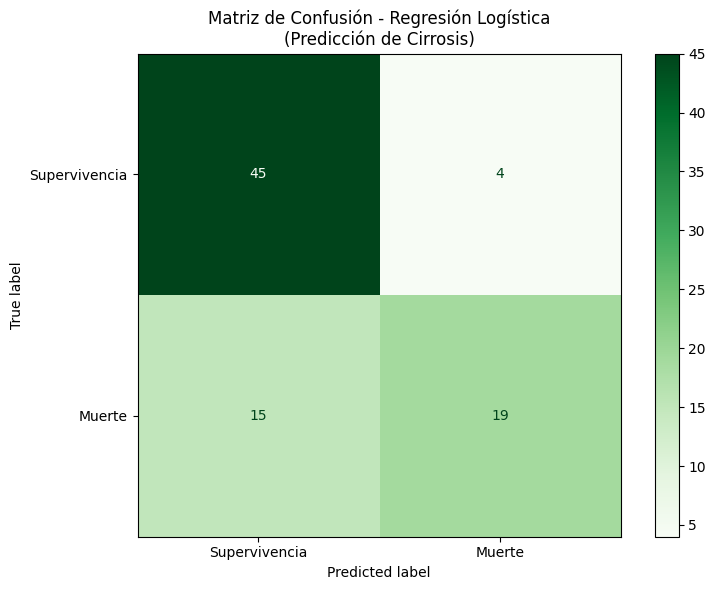

In [9]:
# Crear figura
fig, ax = plt.subplots(figsize=(8, 6))

# Plot confusion matrix
conf_matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Supervivencia', 'Muerte'])
conf_matrix.plot(ax=ax, cmap='Greens')

plt.title('Matriz de Confusión - Regresión Logística\n(Predicción de Cirrosis)')
plt.tight_layout()
plt.show()

## 10. Guardar modelo, scaler y datos de prueba

In [10]:
# Directorio para guardar modelos
model_dir = '.'

# Guardar modelo
model_path = os.path.join(model_dir, 'cirrhosis_logistic_model.pkl')
joblib.dump(logreg, model_path)
print(f"Modelo guardado: {model_path}")

# Guardar scaler
scaler_path = os.path.join(model_dir, 'cirrhosis_logistic_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler guardado: {scaler_path}")

Modelo guardado: .\cirrhosis_logistic_model.pkl
Scaler guardado: .\cirrhosis_logistic_scaler.pkl


## 11. Guardar datos de prueba y métricas como JSON

In [11]:
# Preparar datos de prueba para batch prediction
test_data = {
    "X_test": X_test.values.tolist(),
    "y_test": y_test.values.tolist(),
    "y_pred": y_pred.tolist(),
    "feature_names": feature_cols
}

# Guardar test data
test_data_path = os.path.join(model_dir, 'cirrhosis_logistic_test_data.json')
with open(test_data_path, 'w') as f:
    json.dump(test_data, f, indent=2)

# Preparar métricas
metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "sensitivity": float(sensitivity),
    "specificity": float(specificity),
    "confusion_matrix": {
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn)
    }
}

# Guardar métricas
metrics_path = os.path.join(model_dir, 'cirrhosis_logistic_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)